#Multiclass Logistic Regression with SGD
###Goal: Impliment Multiclass Logistic Regression using stochastic gradient descent on MNIST dataset

In [18]:
# =============================================
# Simple Multiclass Logistic Regression with SGD
# Full MNIST (10 classes)
# =============================================

import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split #for dataset preposessing split
import matplotlib.pyplot as plt
import seaborn as sns

##Load Data

In [19]:
# ------------------- Load Data -------------------
print("Downloading MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data.astype(float)
y = mnist.target.astype(int)

# Normalize
X = X / 255.0

# Add bias term
# X_bias = np.c_[np.ones(len(X)), X]

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Add bias term
X_train_bias = np.c_[np.ones(len(X_train)), X_train]
X_test_bias  = np.c_[np.ones(len(X_test)), X_test]


print(f"Dataset: {X.shape[0]} samples, {X.shape[1]-1} features")

print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

Dataset: 70000 samples, 783 features
Train samples: 56000 | Test samples: 14000


##Softmax for classification

In [20]:
# ------------------- Softmax & SGD -------------------
def softmax(scores):
    exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


##Stochastic Gradient Descent for taining multiclass with batch size

In [21]:
def sgd_multiclass(X, y, epochs=50, lr=0.3, batch_size=128):
    N, D = X.shape
    K = 10
    W = np.zeros((D, K))

    for epoch in range(epochs):
        # Shuffle
        idx = np.random.permutation(N)
        X_shuf = X[idx]
        y_shuf = y[idx]

        for i in range(0, N, batch_size):
            Xb = X_shuf[i:i+batch_size]
            yb = y_shuf[i:i+batch_size]

            scores = Xb @ W
            probs = softmax(scores)

            # One-hot
            onehot = np.zeros((len(yb), K))
            onehot[np.arange(len(yb)), yb] = 1

            grad = Xb.T @ (probs - onehot) / len(yb)
            W -= lr * grad

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} completed")

    return W

##Pure SGD / Full Gradient
###Pros of No Batch (Full Gradient):

- Very stable updates
- Smooth convergence
- Simpler code

###Cons:

- Extremely slow on large datasets (like full MNIST)
- High memory usage
- Can get stuck in local minima more easily
- Not practical for big data

In [22]:
#def sgd_no_batch(X, y, epochs=100, lr=0.1):
#    N, D = X.shape
#    K = 10
#    W = np.zeros((D, K))
#
#    for epoch in range(epochs):
#        scores = X @ W
#        probs = softmax(scores)
#
#        onehot = np.zeros((N, K))
#        onehot[np.arange(N), y] = 1
#
#        grad = X.T @ (probs - onehot) / N
#        W -= lr * grad
#
#        if (epoch + 1) % 20 == 0:
#            print(f"Epoch {epoch+1} done")
#
#    return W

##Taining Multiclass SGD

In [23]:
# ------------------- Train -------------------
print("Training Multiclass SGD...")
#W = sgd_multiclass(X_bias, y, epochs=60, lr=0.25, batch_size=128)

W = sgd_multiclass(X_train_bias, y_train, epochs=60, lr=0.25, batch_size=128)

#W = train_sgd(X_train_bias, y_train, epochs=60, lr=0.25)
#W = sgd_no_batch(X_bias, y, epochs=60, lr=0.25, batch_size=128)

Training Multiclass SGD...
Epoch 10/60 completed
Epoch 20/60 completed
Epoch 30/60 completed
Epoch 40/60 completed
Epoch 50/60 completed
Epoch 60/60 completed


##Model Evaluation or Testing

Evaluating on Test Set...

Test Accuracy: 92.12%


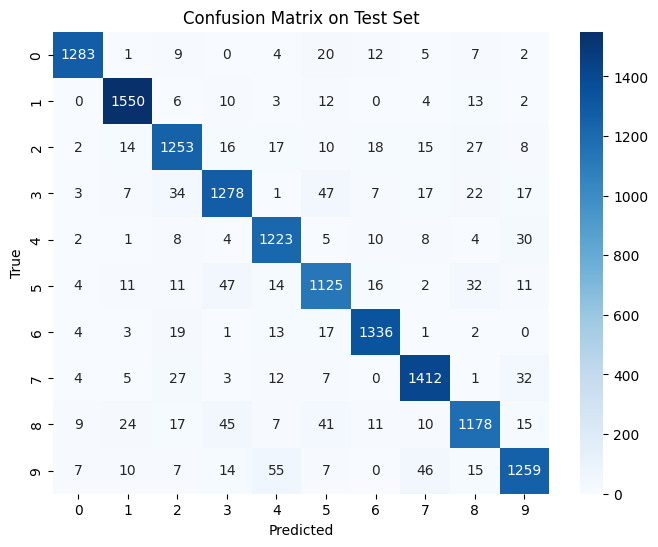

In [24]:
# ------------------- Evaluate -------------------
#scores = X_bias @ W
#y_pred = np.argmax(scores, axis=1)

#acc = accuracy_score(y, y_pred) * 100
#print(f"\nFinal Accuracy: {acc:.2f}%")

# Confusion Matrix (optional)
#cm = confusion_matrix(y, y_pred)
#plt.figure(figsize=(8,6))
#sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
#plt.title('Confusion Matrix - Multiclass')
#plt.xlabel('Predicted')
#plt.ylabel('True')
#plt.show()

# Test on separate test set
print("Evaluating on Test Set...")
scores_test = X_test_bias @ W
y_pred = np.argmax(scores_test, axis=1)

acc = accuracy_score(y_test, y_pred) * 100
print(f"\nTest Accuracy: {acc:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()